In [1]:
import matplotlib.pyplot as plt
import numpy as np

from MCTDHF_direct_jax import *
from electron_integrals import *

import jax.numpy as jnp
from jax import jit

Define number of electrons and orbitals

In [37]:
# Number of spatial orbitals
num_spatial_orbitals = 21
# Number of electrons
num_alpha_electrons = 1
num_beta_electrons = 0
# Number of MCTDHF orbitals
num_mctdhf_orbitals = 1

Calculate electron integrals

In [25]:
class PTPotential:
    def __init__(self, l=10):
        self.l = l

    def __call__(self, x):
        return -0.5*self.l*(self.l+1)/(np.cosh(x)**2)

class PTPot2:
    def __init__(self, depth= 10, width = 10):
        self.depth = depth
        self.width = 2*np.log(np.sqrt(2)+1)/width

    def __call__(self, x):
        return -self.depth/np.cosh(self.width*x)**2

In [38]:
kappa = 1.0
eu = 27.21/kappa**2;        # is the energy unit, given in eV.

lu = np.sqrt(76200/eu)      # is the length unit, given in pm.
tu = 658.2/eu               # is the time unit, given in as.

fe = 1000*(eu/4.136);   # is the photonic frequency conversion factor, given in THz.

print(f"eu = {eu} eV")
print(f"lu = {lu} pm")
print(f"tu = {tu} as")
print(f"fe = {fe} THz")

eu = 27.21 eV
lu = 52.91919325096487 pm
tu = 24.189636163175305 as
fe = 6578.8201160541585 THz


In [39]:
x_max = 2000/lu
num_points = 401
x = np.linspace(-x_max, x_max, num_points)

d = 5/eu
w = 500/lu

pot = PTPot2(d, w)

In [40]:
spf, h = get_spf_and_diag_h(num_spatial_orbitals, x, pot)
g = coulomb_interaction_matrix_elements(spf, spf, x, x, kappa = 1, a = 0.25)

def get_MCTDHF(h, ht, g, num_mctdhf_orbitals, num_spatial_orbitals, 
                 num_alpha_electrons, num_beta_electrons, imag_time=False):

    return MCTDHF(h, ht, g, num_mctdhf_orbitals, num_spatial_orbitals, 
                  num_alpha_electrons, num_beta_electrons, imag_time)

In [13]:
# Sinc-DVR (Same parameters as in Zhangellini)

def kinetic_energy_mels(i, j, dx):
    with np.errstate(divide='ignore'):
        return np.where(
            i==j,
            np.pi ** 2 / (6 * dx ** 2),
            (-1.0) ** (i_min_j := i - j) / (dx ** 2 * i_min_j **2),
        )

grid = np.linspace(-10, 10, num_spatial_orbitals)
x = grid
dx = np.abs(grid[1] - grid[0])
inds=np.arange(len(grid))

pot = lambda x, omega=0.25: 0.5 * omega**2 * x ** 2

t = kinetic_energy_mels(inds[:, None], inds[None, :], dx)
h = t + np.diag(pot(grid))
g = shielded_coulomb(grid[:, None], grid[None, :], kappa=1, a=0.25)

def xi(i, grid=grid, dx=dx):
    return np.sinc(((grid-grid[i])/dx))/np.sqrt(dx)

spf = np.array([xi(i) for i in range(num_spatial_orbitals)])

def get_MCTDHF(h, ht, g, num_mctdhf_orbitals, num_spatial_orbitals, 
                 num_alpha_electrons, num_beta_electrons, imag_time=False):

    return MCTDHF_sinc(h, ht, g, num_mctdhf_orbitals, num_spatial_orbitals, 
                  num_alpha_electrons, num_beta_electrons, imag_time)

Imaginary time propagation

In [41]:
mctdhf = get_MCTDHF(h, lambda t: 0, g, num_mctdhf_orbitals, 
                num_spatial_orbitals, num_alpha_electrons, 
                num_beta_electrons, imag_time=True)

ts, Es, Cs, bs = mctdhf.integrate(num_steps = 5000, dt = 1e-2)

Plot

In [42]:
def plot_Cbe(ts, Cs, bs, Es):
    bs = np.array(bs)
    Es = np.array(Es)
    Cs = np.array(Cs)

    fig, axs = plt.subplots(1, 3, figsize=(16,6))
    axs[0].plot(ts, np.real(Cs))
    axs[0].set_title('Cs')
    axs[1].plot(ts, np.real(bs.reshape(-1, num_spatial_orbitals, num_mctdhf_orbitals)[:,:,0]))
    axs[1].set_title('bs')
    axs[2].plot(ts, np.real(Es))
    axs[2].set_title('E')
    
    plt.show()

Final energy: (-0.1350032091140747+0j)
Max overlap coeff (ideally zero): 1.1920928955078125e-07


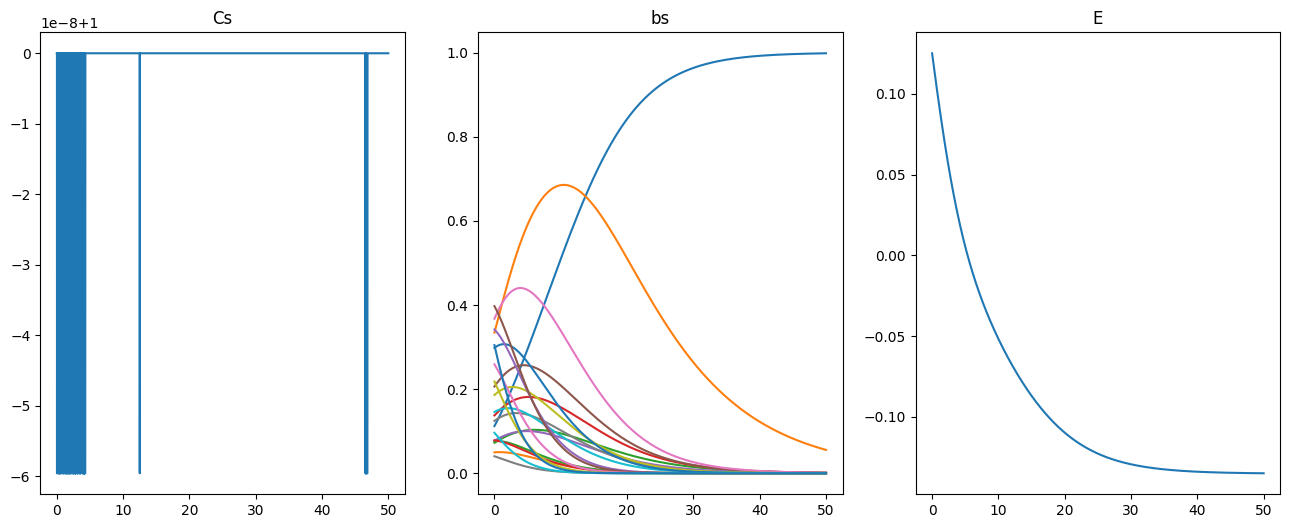

In [43]:
b_f = bs[-1]
print(f"Final energy: {Es[-1]}")
print(f"Max overlap coeff (ideally zero): {np.abs(np.max(b_f.T@b_f-np.eye(num_mctdhf_orbitals)))}")

plot_Cbe(ts, Cs, bs, Es)

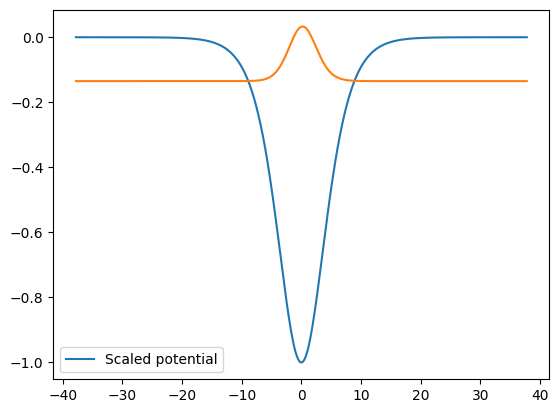

In [44]:
plt.plot(x, pot(x)/np.max(np.abs(pot(x))), label='Scaled potential')
plt.plot(x, Es[-1]+mctdhf.calculate_particle_density(bs[-1], Cs[-1], spf))
plt.legend()
plt.show()

Real time evolution

In [17]:
ht = (x[1]-x[0])*contract('ij, j, kj -> ik', spf.conj(), x, spf)

@jit
def h_t(t, ht=ht):
    return ht*jnp.sin(2*t)

In [18]:
mctdhf_rt = get_MCTDHF(h, h_t, g, num_mctdhf_orbitals, 
                num_spatial_orbitals, num_alpha_electrons, 
                num_beta_electrons, imag_time=False)

dt = 1e-2
num_steps = int(4*2*np.pi/(0.25*8*dt))

ts_rt, Es_rt, Cs_rt, bs_rt = mctdhf_rt.integrate(num_steps = num_steps, dt = dt, t_init = 0, 
                                                b_init = jnp.array(bs[-1]), C_init = jnp.array(Cs[-1]))

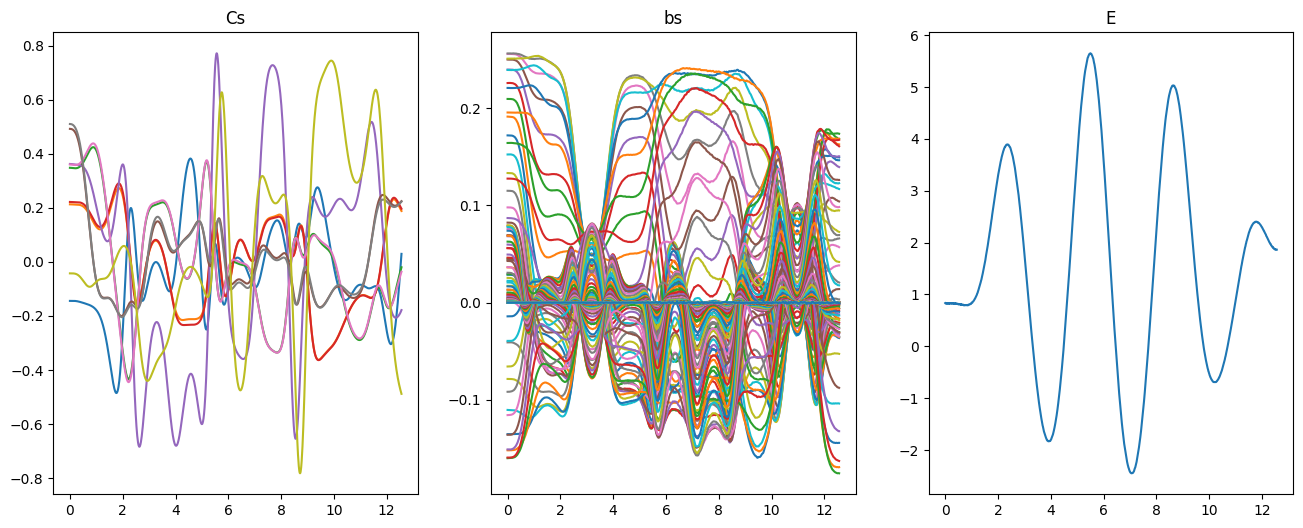

In [19]:
plot_Cbe(ts_rt, Cs_rt, bs_rt, Es_rt)

In [20]:
overlap = [mctdhf.calculate_overlap(bs[-1], Cs[-1], b, C) for b,C in zip(bs_rt, Cs_rt)]

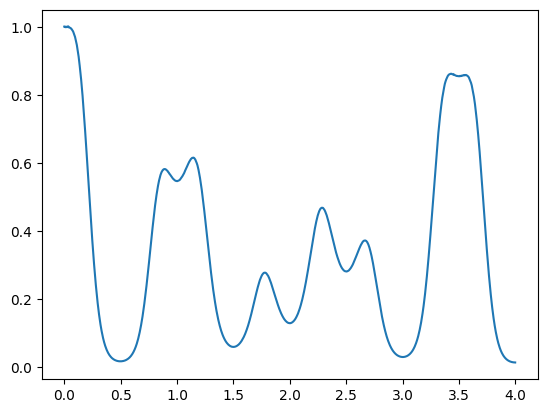

In [21]:
plt.plot(np.array(ts_rt)*0.25*8/(2*np.pi), np.abs(overlap)**2)
plt.show()

## Compare with Zhangellini

In [22]:
dt = 1e-2
num_steps = int(4*2*np.pi/(0.25*8*dt))

Ms = [1,2,3,4]

particle_densities = np.zeros((len(Ms), len(x)))
overlaps = np.zeros((len(Ms), num_steps+1))
gs_energies = np.zeros_like(Ms, np.double)

for i,M in enumerate(Ms):

    mctdhf = get_MCTDHF(h, lambda t: 0, g, M, 
                    num_spatial_orbitals, num_alpha_electrons, 
                    num_beta_electrons, imag_time=True)

    ts, Es, Cs, bs = mctdhf.integrate(num_steps = 5000, dt = 1e-2)
    particle_densities[i,:] = mctdhf.calculate_particle_density(bs[-1], Cs[-1], spf)
    gs_energies[i] = np.real(np.array(Es[-1]))

    mctdhf_rt = get_MCTDHF(h, h_t, g, M, 
                num_spatial_orbitals, num_alpha_electrons, 
                num_beta_electrons, imag_time=False)


    ts_rt, Es_rt, Cs_rt, bs_rt = mctdhf_rt.integrate(num_steps = num_steps, dt = dt, t_init = 0, 
                                                b_init = jnp.array(bs[-1]), C_init = jnp.array(Cs[-1]))

    overlaps[i,:] = np.abs(np.array([mctdhf.calculate_overlap(bs[-1], Cs[-1], b, C) for b,C in zip(bs_rt, Cs_rt)]))**2

Ground state energies
M=1: 1.1796600818634033
M=2: 0.8594634532928467
M=3: 0.8325561285018921
M=4: 0.8314194083213806


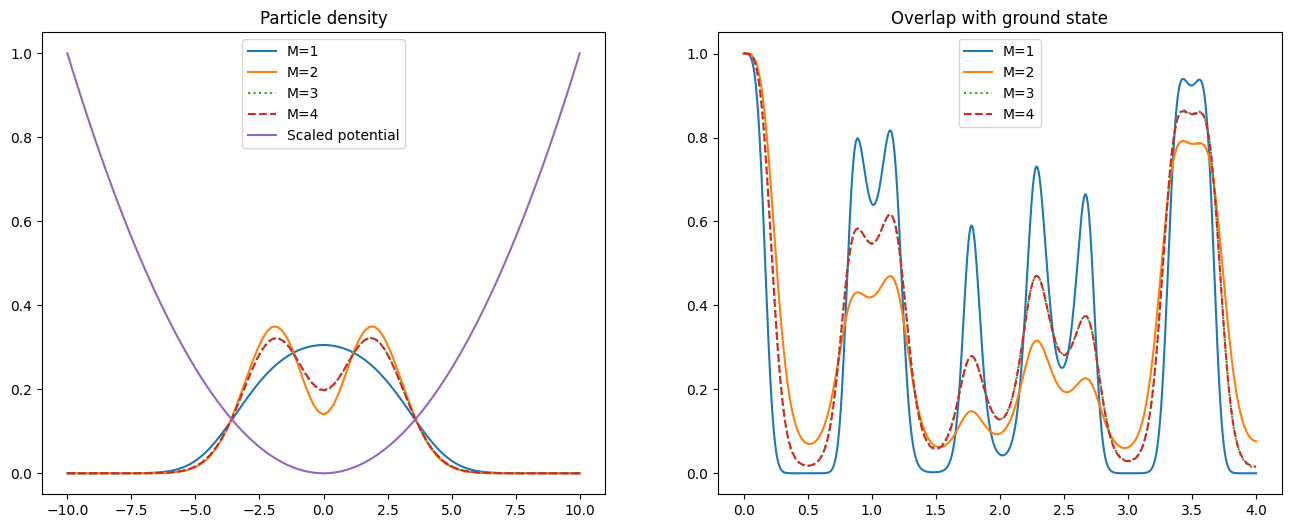

In [23]:
t = np.linspace(0, 4, num_steps+1)
styles = ['-', '-', ':', '--']


fig, axs = plt.subplots(1, 2, figsize=(16,6))

print("Ground state energies")
for i,M in enumerate(Ms):
    print(f'M={M}: {gs_energies[i]}')
    axs[0].plot(x, particle_densities[i], label=f'M={M}', ls=styles[i])
    axs[1].plot(t, overlaps[i], label=f'M={M}', ls=styles[i])


axs[0].plot(x, pot(x)/np.max(pot(x)), label='Scaled potential')

axs[0].set_title('Particle density')
axs[1].set_title('Overlap with ground state')

for a in axs:
    a.legend()
plt.show()
